In [1]:
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
plt.style.use(['science','no-latex'])
import json

## Benchmark

### Penetration = 0

In [3]:
from envs.Bottleneck import Bottleneck

config = {"theta":0, "compliance":1, "eta":0.02, "mode": 'model_based'}
ue = Bottleneck(config)

cost_set = []
action = np.random.rand(ue.action_dim)


for iter in range(10):
    if iter%1 ==0:
        print(iter)
    cost = 0
    ue.reset()
    for i in range(200):
        _, r, _, _ ,_ = ue.step(action)
        cost += r


    cost_set.append(cost)

cost_np = np.array(cost_set)
print(cost_np)
np.save('results/Bottleneck/Bottleneck_ModelBased_UE.npy', cost_np)

0
1
2
3
4
5
6
7
8
9
[-226.5248667  -226.51438122 -226.52621279 -226.4582316  -226.4976152
 -226.30548359 -226.42450941 -226.5890832  -226.77238244 -226.43298471]


### Theoretical LB

In [15]:
SO = ((1.5*7.5)/2 + (0.5*7.5)/2)/2
SO /= ue.max_rew
print(SO)

action = np.random.rand(ue.action_dim)
cost_set = []
for iter in range(10):
    if iter%1 ==0:
        print(iter)
    cost = 0
    ue.reset()
    _, r, _, _ ,_ = ue.step(action)
    cost = -r
    cost += 199 * SO
    cost_set.append(cost)
cost_set = np.array(cost_set)
print(cost_set)
np.save('results/Bottleneck/Bottleneck_ModelBased_SO.npy', cost_set)

0.6572312554670171
0
1
2
3
4
5
6
7
8
9
[131.77159783 132.0070813  131.84686998 131.72041622 131.71946963
 131.84135851 131.80999073 131.77265385 131.86001737 131.82910098]


## Training process

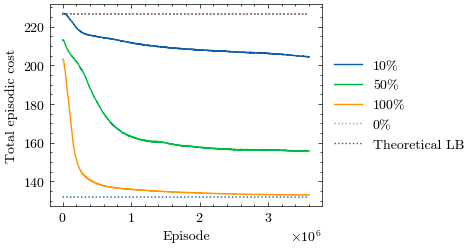

0.008324363950489107


In [2]:
def data_acq(theta, UB, LB, norm=True):
    mean = np.load('results/Bottleneck/Mean_theta='+theta+'_eta=0.02_compliance=1.0.npy')
    std = np.load('results/Bottleneck/Std_theta='+theta+'_eta=0.02_compliance=1.0.npy')
    index = np.load('results/Bottleneck/index.npy')
    range = np.logical_and(index<UB, index>LB)
    index = index.astype(int)
    mean_seq = mean[range]
    max_seq = mean[range]+std[range]
    min_seq = mean[range]-std[range]
    if norm:
        mean_seq = (mean_seq - so_avg)/ (ue_avg-so_avg)
        max_seq = (max_seq - so_avg)/ (ue_avg-so_avg)
        min_seq = (min_seq - so_avg)/ (ue_avg-so_avg)
    return index[range], mean_seq, max_seq, min_seq

benchmark_ue = -np.load('results/Bottleneck/Bottleneck_ModelBased_UE.npy')
benchmark_so = np.load('results/Bottleneck/Bottleneck_ModelBased_SO.npy')

so_avg = np.average(benchmark_so)
ue_avg = np.average(benchmark_ue)

UB = 6e7
#LB = 6e6
LB = 0

smooth = 10

theta = '0.1'
index, mean_seq, max_seq, min_seq = data_acq(theta, UB, LB, False)

plt.plot(index[::smooth], mean_seq[::smooth], label = '10%')
plt.fill_between(index, max_seq, min_seq, alpha=0.2)

theta = '0.5'
index, mean_seq, max_seq, min_seq = data_acq(theta, UB, LB, False)
plt.plot(index[::smooth], mean_seq[::smooth], label = '50%')
plt.fill_between(index, max_seq, min_seq, alpha=0.2)

theta = '1.0'
index, mean_seq, max_seq, min_seq = data_acq(theta, UB, LB, False)
plt.plot(index[::smooth], mean_seq[::smooth], label = '100%')
plt.fill_between(index, max_seq, min_seq, alpha=0.2)

plt.plot(index, np.ones(index.shape)*ue_avg, ':')
plt.plot(index, np.ones(index.shape)*ue_avg, ':')
plt.plot(index, np.ones(index.shape)*ue_avg, ':')

plt.plot(index, np.ones(index.shape)*ue_avg, ':', label='0%')
plt.plot(index, np.ones(index.shape)*so_avg, ':', label='Theoretical LB')

plt.xlabel('Episode')
plt.ylabel('Total episodic cost')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig('results/Bottleneck/Training', dpi=300)
plt.show()
# plt.yscale('log')
print((mean_seq[-1]-so_avg)/so_avg)

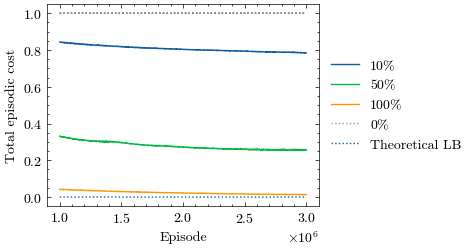

In [22]:
UB = 3e6
LB = 1e6
smooth = 10

theta = '0.1'
index, mean_seq, max_seq, min_seq = data_acq(theta, UB, LB, True)

plt.plot(index[::smooth], mean_seq[::smooth], label = '10%')
plt.fill_between(index, max_seq, min_seq, alpha=0.2)

theta = '0.5'
index, mean_seq, max_seq, min_seq = data_acq(theta, UB, LB, True)
plt.plot(index[::smooth], mean_seq[::smooth], label = '50%')
plt.fill_between(index, max_seq, min_seq, alpha=0.2)

theta = '1.0'
index, mean_seq, max_seq, min_seq = data_acq(theta, UB, LB, True)
plt.plot(index[::smooth], mean_seq[::smooth], label = '100%')
plt.fill_between(index, max_seq, min_seq, alpha=0.2)

plt.plot(index, np.ones(index.shape), ':')
plt.plot(index, np.ones(index.shape), ':')
plt.plot(index, np.ones(index.shape), ':')
plt.plot(index, np.ones(index.shape), ':', label='0%')
plt.plot(index, np.zeros(index.shape), ':', label='Theoretical LB')

plt.xlabel('Episode')
plt.ylabel('Total episodic cost')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig('results/Bottleneck/Training_detail',dpi=300)
plt.show()
# plt.yscale('log')


## Resulting departure profile

In [2]:
from envs.Bottleneck import Bottleneck
config = {"theta":1, "compliance":1, "eta":0.02, "mode": 'model_based'}
so = Bottleneck(config)

traj = np.load('results/Bottleneck/Bottleneck_trajectory.npy')
print(traj.shape)

traj_avg = np.average(traj, axis=0)
traj_std = np.std(traj, axis=0)
traj_max = traj_avg + traj_std
traj_min = traj_avg - traj_std

traj_acc = np.copy(traj)

for trail in range(3):
    for day in range(10):
        traj_acc[trail, day] = np.cumsum(traj[trail, day])

traj_acc_avg = np.average(traj_acc, axis=0)
traj_acc_std = np.std(traj_acc, axis=0)
traj_acc_max = traj_acc_avg + traj_acc_std
traj_acc_min = traj_acc_avg - traj_acc_std

print(traj_avg.shape)

so_rate = np.zeros(60)
so_rate[int(0.5*20): int(2.5*20)] = 1
so_rate /= np.sum(so_rate)
so_profile = np.cumsum(so_rate)

(3, 10, 60)
(10, 60)


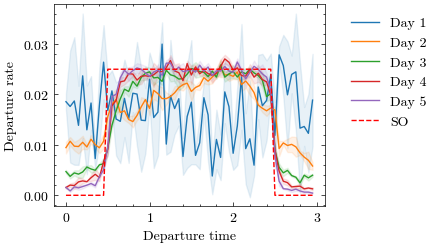

In [9]:
horizon = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for day in range(horizon):
    plt.plot(np.arange(60)*3/60, traj_avg[day,:], color = colors[day], label='Day '+str(day+1))
    plt.fill_between(np.arange(60)*3/60, traj_max[day,:], traj_min[day,:], color = colors[day],  alpha=0.1)

plt.plot(np.arange(60)*3/60, so_rate, '--', label='SO', color = 'r')
plt.legend(loc=2, bbox_to_anchor=(1.05, 1))
plt.xlabel('Departure time')
plt.ylabel('Departure rate')
plt.savefig('results/Bottleneck/Bottleneck_rate',dpi=300)
plt.show()

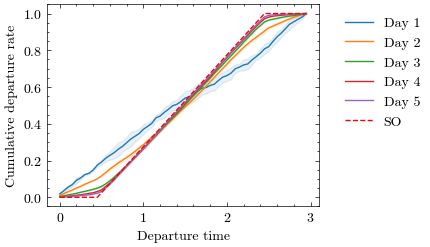

In [32]:
horizon = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for day in range(horizon):
    plt.plot(np.arange(60)*3/60, traj_acc_avg[day,:], color = colors[day], label='Day '+str(day+1))
    plt.fill_between(np.arange(60)*3/60, traj_acc_max[day,:], traj_acc_min[day,:], color = colors[day],  alpha=0.1)

plt.plot(np.arange(60)*3/60, so_profile, '--', label='SO', color = 'r')
plt.legend(loc=2, bbox_to_anchor=(1.05, 1))
plt.xlabel('Departure time')
plt.ylabel('Cumulative departure rate')
plt.savefig('results/Bottleneck/Bottleneck_profile',dpi=300)
plt.show()

(3, 5, 60)


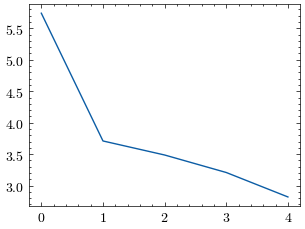

In [6]:
config = {"theta":0.5, "compliance":1, "eta":0.02, "mode": 'model_based'}
mix = Bottleneck(config)

traj_CAV = np.load('results/Bottleneck/Bottleneck_CAVtrajectory_theta=0.5.npy')
traj_HV = np.load('results/Bottleneck/Bottleneck_HVtrajectory_theta=0.5.npy')
traj_mix = (traj_CAV+traj_HV)/2

print(traj_mix.shape)

HV_cost = []
for day in range(5):
    cost_table = mix._travel_cost_table_generate(traj_CAV[0,day,:], traj_HV[0,day,:])
    HV_cost.append(np.sum(traj_HV[0,day,:] @ cost_table * mix.max_rew))

plt.plot(HV_cost)

## Stability

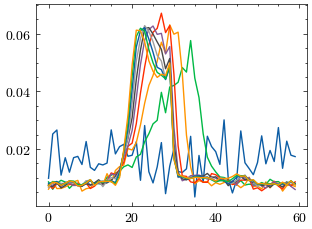

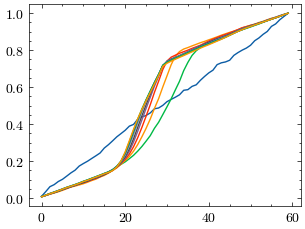

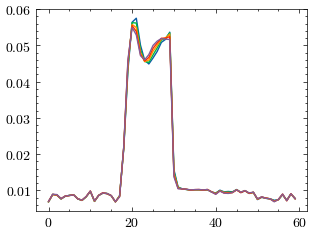

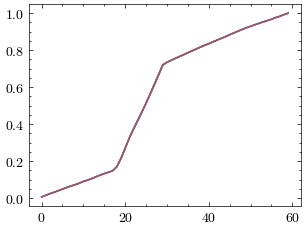

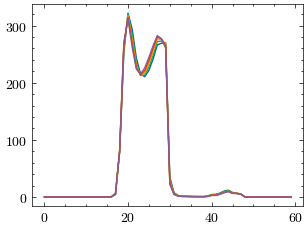

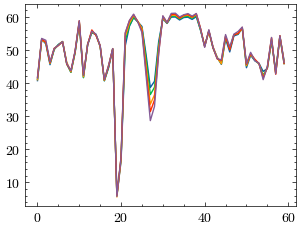

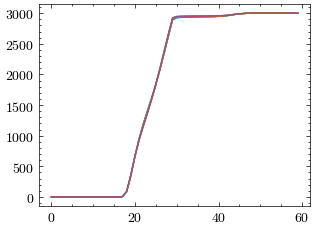

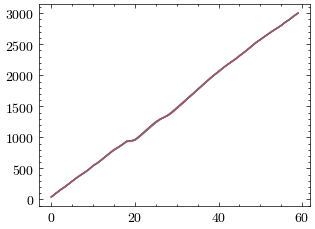

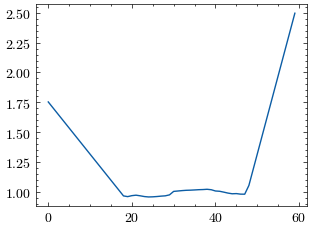

In [6]:
from envs.Bottleneck_stable import Bottleneck_stable
config = {"theta":0.5, "compliance":1, "eta":0.02, "mode": 'model_based'}
mix = Bottleneck_stable(config)

traj_CAV = np.load('results/Bottleneck/BottleneckStable_CAVtrajectory_theta=0.5.npy')
# traj_CAV_avg = np.average(traj_CAV, axis=0)
traj_HV = np.load('results/Bottleneck/BottleneckStable_HVtrajectory_theta=0.5.npy')
# traj_HV_avg = np.average(traj_HV, axis=0)
traj_mix = (traj_CAV+traj_HV)/2
# traj_mix_avg = np.average(traj_mix, axis=0)
# traj_mix_std = np.std(traj_mix, axis=0)
# traj_mix_max = traj_mix_avg + traj_mix_std
# traj_mix_min = traj_mix_avg - traj_mix_std


for t in range(100):
    if t %10 == 0:
        plt.plot(traj_mix[0,t])
plt.savefig('results/Bottleneck/Bottleneck_stable_PDF_converging',dpi=300)
plt.show()

for t in range(100):
    if t %10 == 0:
        plt.plot(np.cumsum(traj_mix[0, t]))
plt.savefig('results/Bottleneck/Bottleneck_stable_CDF_converging',dpi=300)
plt.show()

for t in range(150, 200):
    if t %10 == 0:
        plt.plot(traj_mix[0, t])
plt.savefig('results/Bottleneck/Bottleneck_stable_PDF',dpi=300)
plt.show()

for t in range(150, 200):
    if t %10 == 0:
        plt.plot(np.cumsum(traj_mix[0, t]))
plt.savefig('results/Bottleneck/Bottleneck_stable_CDF',dpi=300)
plt.show()

for t in range(150, 200):
    if t %10 == 0:
        plt.plot(traj_HV[0, t]*mix.inflow/2)
plt.savefig('results/Bottleneck/Bottleneck_stable_HV_PDF',dpi=300)
plt.show()

for t in range(150, 200):
    if t %10 == 0:
        plt.plot(traj_CAV[0, t]*mix.inflow/2)
plt.savefig('results/Bottleneck/Bottleneck_stable_CAV_PDF',dpi=300)
plt.show()

for t in range(150, 200):
    if t %10 == 0:
        plt.plot(np.cumsum(traj_HV[0, t])*mix.inflow/2)
plt.savefig('results/Bottleneck/Bottleneck_stable_HV_CDF',dpi=300)
plt.show()

for t in range(150, 200):
    if t %10 == 0:
        plt.plot(np.cumsum(traj_CAV[0, t])*mix.inflow/2)
plt.savefig('results/Bottleneck/Bottleneck_stable_CAV_CDF',dpi=300)
plt.show()

cost = mix._travel_cost_table_generate(traj_CAV[0, -1], traj_HV[0, -1])
plt.plot(cost)

### Joint version

In [3]:
from envs.Bottleneck import Bottleneck
config = {"theta":1, "compliance":1, "eta":0.02, "mode": 'model_based'}
so = Bottleneck(config)

traj = np.load('results/Bottleneck/Bottleneck_trajectory.npy')

traj_avg = np.average(traj, axis=0)
traj_std = np.std(traj, axis=0)
traj_max = traj_avg + traj_std
traj_min = traj_avg - traj_std

traj_acc = np.copy(traj)

for trail in range(3):
    for day in range(10):
        traj_acc[trail, day] = np.cumsum(traj[trail, day])

traj_acc_avg = np.average(traj_acc, axis=0)
traj_acc_std = np.std(traj_acc, axis=0)
traj_acc_max = traj_acc_avg + traj_acc_std
traj_acc_min = traj_acc_avg - traj_acc_std

print(traj_avg.shape)

so_rate = np.zeros(60)
so_rate[int(0.5*20): int(2.5*20)] = 1
so_rate /= np.sum(so_rate)
so_profile = np.cumsum(so_rate)



traj_CAV = np.load('results/Bottleneck/Bottleneck_CAVtrajectory_theta=0.5.npy')
traj_HV = np.load('results/Bottleneck/Bottleneck_HVtrajectory_theta=0.5.npy')
traj_mix = (traj_CAV+traj_HV)/2


traj_mix_avg = np.average(traj_mix, axis=0)
traj_mix_std = np.std(traj_mix, axis=0)
traj_mix_max = traj_mix_avg + traj_mix_std
traj_mix_min = traj_mix_avg - traj_mix_std

traj_mix_acc = np.copy(traj_mix)

for trail in range(3):
    for day in range(5):
        traj_mix_acc[trail, day] = np.cumsum(traj_mix[trail, day])

traj_mix_acc_avg = np.average(traj_mix_acc, axis=0)
traj_mix_acc_std = np.std(traj_mix_acc, axis=0)
traj_mix_acc_max = traj_mix_acc_avg + traj_mix_acc_std
traj_mix_acc_min = traj_mix_acc_avg - traj_mix_acc_std

print(traj_mix_avg.shape)

(10, 60)
(5, 60)


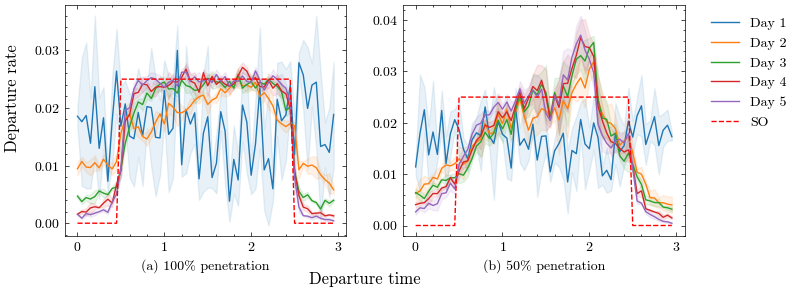

In [23]:
fig, axes = plt.subplots(1,2,figsize=(8,3))

horizon = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for day in range(horizon):
    axes[0].plot(np.arange(60)*3/60, traj_avg[day,:], color = colors[day], label='Day '+str(day+1))
    axes[0].fill_between(np.arange(60)*3/60, traj_max[day,:], traj_min[day,:], color = colors[day],  alpha=0.1)

axes[0].plot(np.arange(60)*3/60, so_rate, '--', label='SO', color = 'r')
axes[0].set_xlabel('(a) 100% penetration')

for day in range(horizon):
    axes[1].plot(np.arange(60)*3/60, traj_mix_avg[day,:], color = colors[day], label='Day '+str(day+1))
    axes[1].fill_between(np.arange(60)*3/60, traj_mix_max[day,:], traj_mix_min[day,:], color = colors[day],  alpha=0.1)

axes[1].plot(np.arange(60)*3/60, so_rate, '--', label='SO', color = 'r')
axes[1].set_xlabel('(b) 50% penetration')

axes[1].legend(loc=2, bbox_to_anchor=(1.05, 1))


fig.text(0.5, -0.05, 'Departure time', ha='center', fontsize=12)
fig.text(0.06, 0.4, 'Departure rate', rotation=90, ha='center', fontsize=12)

plt.savefig('results/Bottleneck/Bottleneck_rate',dpi=300)



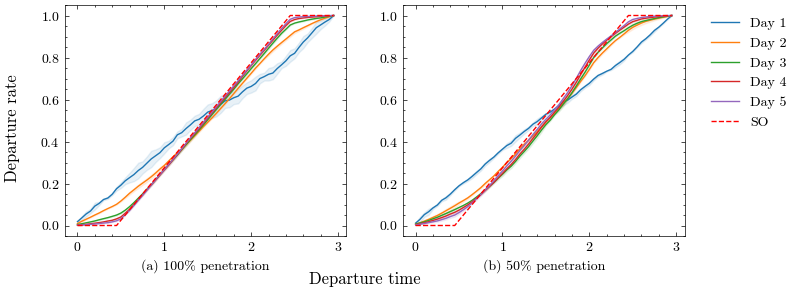

In [4]:
fig, axes = plt.subplots(1,2,figsize=(8,3))

horizon = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for day in range(horizon):
    axes[0].plot(np.arange(60)*3/60, traj_acc_avg[day,:], color = colors[day], label='Day '+str(day+1))
    axes[0].fill_between(np.arange(60)*3/60, traj_acc_max[day,:], traj_acc_min[day,:], color = colors[day],  alpha=0.1)

axes[0].plot(np.arange(60)*3/60, so_profile, '--', label='SO', color = 'r')
axes[0].set_xlabel('(a) 100% penetration')

for day in range(horizon):
    axes[1].plot(np.arange(60)*3/60, traj_mix_acc_avg[day,:], color = colors[day], label='Day '+str(day+1))
    axes[1].fill_between(np.arange(60)*3/60, traj_mix_acc_max[day,:], traj_mix_acc_min[day,:], color = colors[day],  alpha=0.1)

axes[1].plot(np.arange(60)*3/60, so_profile, '--', label='SO', color = 'r')
axes[1].set_xlabel('(b) 50% penetration')

axes[1].legend(loc=2, bbox_to_anchor=(1.05, 1))


fig.text(0.5, -0.05, 'Departure time', ha='center', fontsize=12)
fig.text(0.06, 0.3, 'Departure rate', rotation=90, ha='center', fontsize=12)

plt.savefig('results/Bottleneck/Bottleneck_profile',dpi=300)



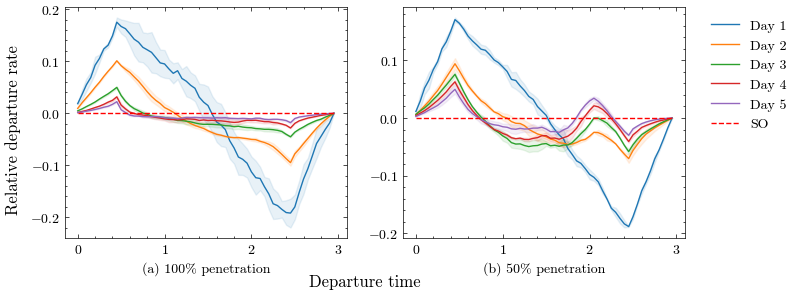

In [5]:
fig, axes = plt.subplots(1,2,figsize=(8,3))

horizon = 5
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for day in range(horizon):
    axes[0].plot(np.arange(60)*3/60, traj_acc_avg[day,:]-so_profile, color = colors[day], label='Day '+str(day+1))
    axes[0].fill_between(np.arange(60)*3/60, traj_acc_max[day,:]-so_profile, traj_acc_min[day,:]-so_profile, color = colors[day],  alpha=0.1)

axes[0].plot(np.arange(60)*3/60, so_profile-so_profile, '--', label='SO', color = 'r')
axes[0].set_xlabel('(a) 100% penetration')

for day in range(horizon):
    axes[1].plot(np.arange(60)*3/60, traj_mix_acc_avg[day,:]-so_profile, color = colors[day], label='Day '+str(day+1))
    axes[1].fill_between(np.arange(60)*3/60, traj_mix_acc_max[day,:]-so_profile, traj_mix_acc_min[day,:]-so_profile, color = colors[day],  alpha=0.1)

axes[1].plot(np.arange(60)*3/60, so_profile-so_profile, '--', label='SO', color = 'r')
axes[1].set_xlabel('(b) 50% penetration')

axes[1].legend(loc=2, bbox_to_anchor=(1.05, 1))


fig.text(0.5, -0.05, 'Departure time', ha='center', fontsize=12)
fig.text(0.06, 0.2, 'Relative departure rate', rotation=90, ha='center', fontsize=12)

plt.savefig('results/Bottleneck/Bottleneck_relative',dpi=300)



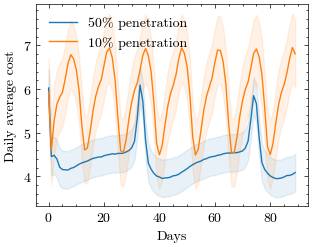

In [2]:
from envs.Bottleneck import Bottleneck
config = {"theta":1, "compliance":1, "eta":0.02, "mode": 'model_based'}
so = Bottleneck(config)

range = 90

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

cost05 = np.load('results/Bottleneck/Bottleneck_SystemCost_theta=0.5.npy')
cost05 *= -so.max_rew
cost05_avg = np.average(cost05, axis=0)
cost05_std = np.std(cost05_avg, axis=0)
cost05_max = cost05_avg + cost05_std
cost05_min = cost05_avg - cost05_std


cost01 = np.load('results/Bottleneck/Bottleneck_SystemCost_theta=0.1.npy')
cost01 *= -so.max_rew
cost01_avg = np.average(cost01, axis=0)
cost01_std = np.std(cost01_avg, axis=0)
cost01_max = cost01_avg + cost01_std
cost01_min = cost01_avg - cost01_std


plt.plot(np.arange(range), cost05_avg[:range], color = colors[0], label='50% penetration')
plt.fill_between(np.arange(range),cost05_max[:range], cost05_min[:range], color = colors[0],  alpha=0.1)
plt.plot(np.arange(range), cost01_avg[:range], color = colors[1], label='10% penetration')
plt.fill_between(np.arange(range),cost01_max[:range], cost01_min[:range], color = colors[1],  alpha=0.1)

plt.legend()
plt.xlabel('Days')
plt.ylabel('Daily average cost')
plt.savefig('results/Bottleneck/Bottleneck_nonconverge',dpi=300)


## Generate mean and std sequence

In [2]:
# Bottleneck
exp = 'Bottleneck'

data = np.load('results/Bottleneck/Trail 1/Index_theta=0.1_eta=0.02_compliance=1.0.npy')
length  = data.shape[0]
for theta in ['0.1', '0.5', '1.0']:
    for trail in range(1,4):
        data = np.load('results/Bottleneck/Trail '+str(trail)+'/Index_theta='+theta+'_eta=0.02_compliance=1.0.npy')
        if data.shape[0]<length:
            length = data.shape[0]
print(length)
index = data[:length]/200
np.save('results/Bottleneck/index.npy', index)
    

for idx in [1,5]:

    cost_agg = np.zeros((3,length))

    for trail in range(1,4):
        reward = np.load('results/Bottleneck/Trail '+str(trail)+'/Reward_theta=0.'+str(idx)+'_eta=0.02_compliance=1.0.npy')
        cost = -reward[0:length]
        cost_agg[trail-1] = cost

    cost_mean = np.mean(cost_agg, axis=0)
    cost_std = np.std(cost_agg, axis=0)
    np.save('results/Bottleneck/Mean_theta=0.'+str(idx)+'_eta=0.02_compliance=1.0.npy', cost_mean)
    np.save('results/Bottleneck/Std_theta=0.'+str(idx)+'_eta=0.02_compliance=1.0.npy', cost_std)
    
    
data = np.load('results/Bottleneck/Trail 1/Index_theta=1.0_eta=0.02_compliance=1.0.npy')
length  = data.shape[0]
for trail in range(1,4):
    data = np.load('results/Bottleneck/Trail '+str(trail)+'/Index_theta=1.0_eta=0.02_compliance=1.0.npy')
    if data.shape[0]<length:
        length = data.shape[0]
print(length)
cost_agg = np.zeros((3,length))

for trail in range(1,4):
    reward = np.load('results/Bottleneck/Trail '+str(trail)+'/Reward_theta=1.0_eta=0.02_compliance=1.0.npy')
    cost = -reward[0:length]
    cost_agg[trail-1] = cost

cost_mean = np.mean(cost_agg, axis=0)
cost_std = np.std(cost_agg, axis=0)
np.save('results/Bottleneck/Mean_theta=1.0_eta=0.02_compliance=1.0.npy', cost_mean)
np.save('results/Bottleneck/Std_theta=1.0_eta=0.02_compliance=1.0.npy', cost_std)

30000
30000
